In [75]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
pd.set_option("display.max_columns", None)
import seaborn as sns
import matplotlib.pyplot as plt

In [76]:
# Para imputación de nulos usando métodos estadísticos avanzados
from sklearn.impute import SimpleImputer 
from sklearn.experimental import enable_iterative_imputer # Necesario para IterativeImputer
from sklearn.impute import IterativeImputer 
from sklearn.impute import KNNImputer 

## FASE 1 - ANÁLISIS EXPLORATORIO INICIAL

In [77]:
df_hr = pd.read_csv("../hr.csv")

In [78]:
def exploracion_basica(df):
    print(f"Las dos primeras filas son:")
    display(df.head(2))
    print("=" * 50)
    print(f"Las dos últimas filas son:")
    display(df.tail(2))
    print("=" * 50)
    print(f"Las dos filas aleatorias son:")
    display(df.sample(2)) 
    print("=" * 50)
    print(f"Información sobre DataFrame:")
    print(df.info())
    print("=" * 50)
    print(f"El dataframe tiene {df.shape[0]} filas y {df.shape[1]} columnas.")
    return df

In [79]:
df_hr = exploracion_basica(df_hr)

Las dos primeras filas son:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,sALES eXECUTIVE,4.0,Single,5993.0,19479,8,Y,Yes,11,3,1,80.0,0,8,0.0,1,6,4,0,5.0
1,49.0,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,rESEARCH sCIENTIST,2.0,Married,5130.0,24907,1,Y,No,23,4,4,NaN,1,10,3.0,3,10,7,1,7.0


Las dos últimas filas son:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1472,24.0,Yes,Travel_Rarely,240,Human Resources,22,1,Human Resources,1,1714,4,Male,58,1,1,hUMAN rESOURCES,3.0,Married,1555.0,11585,1,Y,No,11,3,3,80.0,1,1,2.0,3,1,0,0,0.0
1473,45.0,No,Travel_Rarely,1339,Research & Development,7,3,Life Sciences,1,86,2,Male,59,3,3,rESEARCH sCIENTIST,1.0,Divorced,9724.0,18787,2,Y,No,17,3,3,NaN,1,25,2.0,3,1,0,0,0.0


Las dos filas aleatorias son:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
176,33.0,No,Travel_Rarely,134,Research & Development,2,3,Life Sciences,1,242,3,Male,90,3,1,rESEARCH sCIENTIST,4.0,Single,2500.0,10515,0,Y,No,14,3,1,80.0,0,4,2.0,4,3,1,0,2.0
463,26.0,Yes,Travel_Rarely,471,Research & Development,24,3,Technical Degree,1,622,3,Male,66,1,1,lABORATORY tECHNICIAN,4.0,Single,2340.0,23213,1,Y,Yes,18,3,2,NaN,0,1,3.0,1,1,0,0,0.0


Información sobre DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1474 entries, 0 to 1473
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1401 non-null   float64
 1   Attrition                 1474 non-null   object 
 2   BusinessTravel            1357 non-null   object 
 3   DailyRate                 1474 non-null   int64  
 4   Department                1445 non-null   object 
 5   DistanceFromHome          1474 non-null   int64  
 6   Education                 1474 non-null   int64  
 7   EducationField            1416 non-null   object 
 8   EmployeeCount             1474 non-null   int64  
 9   EmployeeNumber            1474 non-null   int64  
 10  EnvironmentSatisfaction   1474 non-null   int64  
 11  Gender                    1474 non-null   object 
 12  HourlyRate                1474 non-null   int64  
 13  JobInvolvement            1474 non

In [80]:
print(f"El dataframe hr tiene {df_hr.shape[0]} filas y {df_hr.shape[1]} columnas")

El dataframe hr tiene 1474 filas y 35 columnas


In [81]:
#Observaciones:
# Age - está como float, cambiar a int
# Hay nulos en varias columnas 
# EmployeeNumber - no vemos relevancia más que ponerla como Indice 
# posiblemente eliminar: 'employee_count', 'over_18', 'standard_hours', 'monthly_rate', 'daily_rate' ya que no poseen información relevante/ son repetitivas, indican lo mismo que otras columnas
# Cambiar columna Over18 a booleano (True/False) en vez de 'Y'/'N' - o eliminar
# Revisar duplicados
# Revisar outliers

In [82]:
# Cuales son las diferentes categorias de respuesta de todas las columnas categoricas?

col_categoricas = df_hr.select_dtypes(include="object").columns

col_categoricas

for col in col_categoricas:
    print(f"ESTAMOS ANALIZANDO LA COLUMNA {col}")
    print(df_hr[col].unique())
    print("=" * 100)

ESTAMOS ANALIZANDO LA COLUMNA Attrition
['Yes' 'No']
ESTAMOS ANALIZANDO LA COLUMNA BusinessTravel
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel' nan]
ESTAMOS ANALIZANDO LA COLUMNA Department
['Sales' 'Research & Development' nan 'Human Resources']
ESTAMOS ANALIZANDO LA COLUMNA EducationField
['Life Sciences' 'Other' 'Medical' nan 'Marketing' 'Technical Degree'
 'Human Resources']
ESTAMOS ANALIZANDO LA COLUMNA Gender
['Female' 'Male']
ESTAMOS ANALIZANDO LA COLUMNA JobRole
[' sALES eXECUTIVE ' ' rESEARCH sCIENTIST ' ' lABORATORY tECHNICIAN '
 ' mANUFACTURING dIRECTOR ' ' hEALTHCARE rEPRESENTATIVE ' ' mANAGER '
 ' sALES rEPRESENTATIVE ' ' rESEARCH dIRECTOR ' ' hUMAN rESOURCES ']
ESTAMOS ANALIZANDO LA COLUMNA MaritalStatus
['Single' 'Married' 'Divorced' nan 'Marreid']
ESTAMOS ANALIZANDO LA COLUMNA Over18
['Y']
ESTAMOS ANALIZANDO LA COLUMNA OverTime
['Yes' 'No' nan]


In [83]:
# Observaciones:

# Business travel - dejar Rarely, Frenquently, Non-Travel
# JobRole - standarizar informacion (tiene mayusculas y minusculas)
# MaritalStatus - tiene un typo 'Marreid' (corregir)
# Eliminar columna Over18 ya que no contiene informacion relevante

## Limpieza datos: 

- Homogenización columnas
- Eliminación de columnas irrelevantes
- Correción de datos dentro de columnas

In [84]:

df_hr.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [85]:
# queremos añadir _ a los nombres de las columnas y poner en minúscula
#importar regex para insertar guines bajsos antes de mayúsculas internas. Buena práctica
#r'(?<!^)(?=[A-Z])' significa “encuentra cada mayúscula que no esté al inicio, y pon un _ antes”.

In [86]:
import re

def limpiar_columnas(df):
    nuevas_cols = {}

    for col in df.columns:
        # 1. Separar CamelCase
        col = re.sub(r'(?<!^)(?=[A-Z])', '_', col)

        # 2. Separar letras y números (Over18 → Over_18)
        col = re.sub(r'([a-zA-Z])([0-9])', r'\1_\2', col)
        col = re.sub(r'([0-9])([a-zA-Z])', r'\1_\2', col)

        # 3. Minúsculas
        col = col.lower()

        # 4. Limpiar caracteres raros
        col = re.sub(r'[^\w]+', '_', col)

        # 5. Evitar múltiples "_"
        col = re.sub(r'_+', '_', col)

        # 6. Quitar "_" al inicio o final
        col = col.strip('_')

        nuevas_cols[col] = col

    df.columns = nuevas_cols.values()
    return df

In [87]:
limpiar_columnas(df_hr)

,age,attrition,business_travel,daily_rate,department,distance_from_home,education,education_field,employee_count,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,monthly_rate,num_companies_worked,over_18,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,standard_hours,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
0,41.0,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,sALES eXECUTIVE,4.0,Single,5993.0,19479,8,Y,Yes,11,3,1,80.0,0,8,0.0,1,6,4,0,5.0
1,49.0,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,rESEARCH sCIENTIST,2.0,Married,5130.0,24907,1,Y,No,23,4,4,NaN,1,10,3.0,3,10,7,1,7.0
2,37.0,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,lABORATORY tECHNICIAN,3.0,Single,2090.0,2396,6,Y,Yes,15,3,2,NaN,0,7,3.0,3,0,0,0,0.0
3,33.0,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,rESEARCH sCIENTIST,3.0,Married,2909.0,23159,1,Y,Yes,11,3,3,80.0,0,8,3.0,3,8,7,3,0.0
4,27.0,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,lABORATORY tECHNICIAN,2.0,Married,3468.0,16632,9,Y,No,12,3,4,80.0,1,6,3.0,3,2,2,2,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1469,34.0,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,2,Male,82,4,2,lABORATORY tECHNICIAN,3.0,Married,4404.0,10228,2,Y,No,12,3,1,NaN,0,6,3.0,4,4,3,1,2.0
1470,28.0,No,Travel_Rarely,866,Sales,5,3,Medical,1,1469,4,Male,84,3,2,sALES eXECUTIVE,1.0,Single,8463.0,23490,0,Y,No,18,3,4,NaN,0,6,4.0,3,5,4,1,NaN
1471,53.0,No,Travel_Rarely,1084,Research & Development,13,2,Medical,1,250,4,Female,57,4,2,mANUFACTURING dIRECTOR,1.0,Divorced,4450.0,26250,1,Y,No,11,3,3,NaN,2,5,3.0,3,4,2,1,3.0
1472,24.0,Yes,Travel_Rarely,240,Human Resources,22,1,Human Resources,1,1714,4,Male,58,1,1,hUMAN rESOURCES,3.0,Married,1555.0,11585,1,Y,No,11,3,3,80.0,1,1,2.0,3,1,0,0,0.0


In [88]:
# cambiar edad a int

columna_edad_a_int = ['age']

for col in columna_edad_a_int:
    df_hr[col] = df_hr[col].astype('Int64')

df_hr[columna_edad_a_int].dtypes

age    Int64
dtype: object

In [89]:
# homogenizar datos de columna job_role


In [90]:
df_hr['job_role'] = df_hr['job_role'].str.strip().str.lower().str.title()

df_hr['job_role'].unique()

array(['Sales Executive', 'Research Scientist', 'Laboratory Technician',
       'Manufacturing Director', 'Healthcare Representative', 'Manager',
       'Sales Representative', 'Research Director', 'Human Resources'],
      dtype=object)

In [91]:
# 1. cambiar nombre de categorias: 

nuevas_categorias_business_travel = {
    'Travel_Rarely': 'Rarely',
    'Travel_Frequently': 'Frequently',
    'Non-Travel': 'Non_Travel'}


In [92]:
# aplicar el reemplazo
df_hr['business_travel'] = df_hr['business_travel'].replace(nuevas_categorias_business_travel)

In [93]:
df_hr['business_travel'].unique()

array(['Rarely', 'Frequently', 'Non_Travel', nan], dtype=object)

In [94]:
df_hr['business_travel'].value_counts(dropna=False)

business_travel
Rarely        955
Frequently    263
Non_Travel    139
NaN           117
Name: count, dtype: int64

In [95]:
# Corregir datos mal escritos en columna marital_status

df_hr['marital_status'].value_counts(dropna=False)

marital_status
Married     604
Single      437
Divorced    298
NaN         132
Marreid       3
Name: count, dtype: int64

In [96]:
nuevas_categorias_marital_status = {
    'Single': 'Single',
    'Married': 'Married',
    'Divorced': 'Divorced',
    'Marreid': 'Married'
    }

In [97]:
# aplicar el reemplazo
df_hr['marital_status'] = df_hr['marital_status'].replace(nuevas_categorias_marital_status)

In [98]:
# confirmar

df_hr['marital_status'].value_counts(dropna=False)

marital_status
Married     607
Single      437
Divorced    298
NaN         132
Name: count, dtype: int64

In [99]:
df_hr.sample(5)

,age,attrition,business_travel,daily_rate,department,distance_from_home,education,education_field,employee_count,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,monthly_rate,num_companies_worked,over_18,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,standard_hours,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
211,30,No,NaN,829,Research & Development,1,1,Life Sciences,1,292,3,Male,88,2,3,Manufacturing Director,3.0,Single,8474.0,20925,1,Y,No,22,4,3,NaN,0,12,2.0,3,11,8,5,8.0
164,27,No,Non_Travel,1450,Research & Development,3,3,Medical,1,224,3,Male,79,2,1,Research Scientist,3.0,Divorced,2566.0,25326,1,Y,Yes,15,3,4,80.0,1,1,NaN,2,1,1,0,1.0
543,44,No,Non_Travel,381,Research & Development,24,3,Medical,1,744,1,Male,49,1,1,Laboratory Technician,3.0,Single,3708.0,2104,2,Y,No,14,3,3,80.0,0,9,NaN,3,5,2,1,4.0
1229,40,No,Rarely,369,Research & Development,8,2,Life Sciences,1,1724,2,Female,92,3,2,Manufacturing Director,1.0,Married,6516.0,5041,2,Y,Yes,16,3,2,80.0,1,18,3.0,3,1,0,0,0.0
695,37,Yes,NaN,625,Sales,1,4,Life Sciences,1,970,1,Male,46,2,3,Sales Executive,3.0,Married,10609.0,14922,5,Y,No,11,3,3,80.0,0,17,2.0,1,14,1,11,7.0


In [100]:
df_hr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1474 entries, 0 to 1473
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         1401 non-null   Int64  
 1   attrition                   1474 non-null   object 
 2   business_travel             1357 non-null   object 
 3   daily_rate                  1474 non-null   int64  
 4   department                  1445 non-null   object 
 5   distance_from_home          1474 non-null   int64  
 6   education                   1474 non-null   int64  
 7   education_field             1416 non-null   object 
 8   employee_count              1474 non-null   int64  
 9   employee_number             1474 non-null   int64  
 10  environment_satisfaction    1474 non-null   int64  
 11  gender                      1474 non-null   object 
 12  hourly_rate                 1474 non-null   int64  
 13  job_involvement             1474 

In [101]:
df_hr['standard_hours'].unique()

array([80., nan])

In [102]:
# Eliminamos columnas que no aportan información relevante para el análisis o modelado
df_hr = df_hr.drop(columns=['employee_count', 'over_18', 'standard_hours', 'monthly_rate', 'daily_rate'], errors='ignore')

In [103]:
df_hr.head(2)

,age,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
0,41,Yes,Rarely,Sales,1,2,Life Sciences,1,2,Female,94,3,2,Sales Executive,4.0,Single,5993.0,8,Yes,11,3,1,0,8,0.0,1,6,4,0,5.0
1,49,No,Frequently,Research & Development,8,1,Life Sciences,2,3,Male,61,2,2,Research Scientist,2.0,Married,5130.0,1,No,23,4,4,1,10,3.0,3,10,7,1,7.0


In [104]:
print(df_hr.duplicated().sum())

4


In [105]:
mascara_duplicados_hr = df_hr.duplicated(keep=False)         # --> duplicated solo muestra la copia, si queremos ver el original hay que agregar "keep=False"

df_hr[mascara_duplicados_hr].sort_values(by="employee_number")  # --> para verlos en orden

,age,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
67,45,No,Rarely,Research & Development,7,3,Life Sciences,86,2,Male,59,3,3,Research Scientist,1.0,Divorced,9724.0,2,No,17,3,3,1,25,2.0,3,1,0,0,0.0
1473,45,No,Rarely,Research & Development,7,3,Life Sciences,86,2,Male,59,3,3,Research Scientist,1.0,Divorced,9724.0,2,No,17,3,3,1,25,2.0,3,1,0,0,0.0
1471,53,No,Rarely,Research & Development,13,2,Medical,250,4,Female,57,4,2,Manufacturing Director,1.0,Divorced,4450.0,1,No,11,3,3,2,5,3.0,3,4,2,1,3.0
184,53,No,Rarely,Research & Development,13,2,Medical,250,4,Female,57,4,2,Manufacturing Director,1.0,Divorced,4450.0,1,No,11,3,3,2,5,3.0,3,4,2,1,3.0
1470,28,No,Rarely,Sales,5,3,Medical,1469,4,Male,84,3,2,Sales Executive,1.0,Single,8463.0,0,No,18,3,4,0,6,4.0,3,5,4,1,NaN
1041,28,No,Rarely,Sales,5,3,Medical,1469,4,Male,84,3,2,Sales Executive,1.0,Single,8463.0,0,No,18,3,4,0,6,4.0,3,5,4,1,NaN
1222,24,Yes,Rarely,Human Resources,22,1,Human Resources,1714,4,Male,58,1,1,Human Resources,3.0,Married,1555.0,1,No,11,3,3,1,1,2.0,3,1,0,0,0.0
1472,24,Yes,Rarely,Human Resources,22,1,Human Resources,1714,4,Male,58,1,1,Human Resources,3.0,Married,1555.0,1,No,11,3,3,1,1,2.0,3,1,0,0,0.0


In [106]:
df_hr.drop_duplicates(inplace=True)
print(df_hr.duplicated().sum())

0


In [107]:
df_hr['attrition'].value_counts()

attrition
No     1233
Yes     237
Name: count, dtype: int64

In [108]:
filtrado = df_hr[['education_field', 'job_role']].value_counts().reset_index(name='count')
filtrado

,education_field,job_role,count
0,Life Sciences,Research Scientist,128
1,Marketing,Sales Executive,118
2,Life Sciences,Laboratory Technician,114
3,Life Sciences,Sales Executive,101
4,Medical,Research Scientist,98
5,Medical,Laboratory Technician,96
6,Life Sciences,Manufacturing Director,68
7,Medical,Sales Executive,63
8,Life Sciences,Healthcare Representative,57
9,Medical,Manufacturing Director,50


In [109]:
## queremos ver si la columna EmployeeNumber es un identificador único para cada empleado, lo que podría ser útil para eliminar duplicados o para establecerla como índice del DataFrame.

df_hr['employee_number'].nunique() == df_hr.shape[0]

True

In [ ]:
# Si la columna 'employee_number' tiene el mismo número de valores únicos que el número total de filas, entonces es un identificador único para cada empleado. 
# Esto significa que no hay duplicados en esa columna y que cada valor corresponde a un empleado diferente. 
# En este caso, podríamos considerar establecer 'employee_number' como índice del DataFrame para facilitar la identificación y manipulación de los datos relacionados con cada empleado.

# Hemos decidido no establecer 'employee_number' como índice del DataFrame para mantener la flexibilidad en el manejo de los datos, aunque es un identificador único. 
# Esto nos permite realizar operaciones de filtrado, agrupamiento y análisis sin restricciones adicionales que podrían surgir al tener un índice basado en 'employee_number'. 
# Además, mantenerlo como una columna normal facilita su uso en análisis exploratorios y modelado sin necesidad de restablecer el índice posteriormente.

In [110]:
### Análisis descriptivo previo a imputar nulos

In [111]:
def analisis_descriptivo(df):
    print("🔹 NUMÉRICAS")
    display(df.describe(include = "number").T)
    
    print("\n🔹 CATEGÓRICAS")
    display(df.describe(include="object").T)

In [112]:
analisis_descriptivo(df_hr)

🔹 NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
age,1397.0,36.942734,9.095617,18.0,30.0,36.0,43.0,60.0
distance_from_home,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
employee_number,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
environment_satisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.0,4.0
hourly_rate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
job_involvement,1470.0,2.729932,0.711561,1.0,2.0,3.0,3.0,4.0
job_level,1470.0,2.063946,1.10694,1.0,1.0,2.0,3.0,5.0
job_satisfaction,1441.0,2.73213,1.105103,1.0,2.0,3.0,4.0,4.0
monthly_income,1456.0,6498.683379,4709.394593,1009.0,2909.0,4907.0,8353.5,19999.0



🔹 CATEGÓRICAS


,count,unique,top,freq
attrition,1470,2,No,1233
business_travel,1353,3,Rarely,951
department,1441,3,Research & Development,939
education_field,1412,6,Life Sciences,581
gender,1470,2,Male,882
job_role,1470,9,Sales Executive,326
marital_status,1338,3,Married,606
over_time,1426,2,No,1021


## Gestión datos nulos:

In [113]:
df_hr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1470 entries, 0 to 1469
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         1397 non-null   Int64  
 1   attrition                   1470 non-null   object 
 2   business_travel             1353 non-null   object 
 3   department                  1441 non-null   object 
 4   distance_from_home          1470 non-null   int64  
 5   education                   1470 non-null   int64  
 6   education_field             1412 non-null   object 
 7   employee_number             1470 non-null   int64  
 8   environment_satisfaction    1470 non-null   int64  
 9   gender                      1470 non-null   object 
 10  hourly_rate                 1470 non-null   int64  
 11  job_involvement             1470 non-null   int64  
 12  job_level                   1470 non-null   int64  
 13  job_role                    1470 non-n

In [114]:
# filtramos datos categoricos

df_hr_cat = df_hr.select_dtypes(include="object")

df_hr_cat  

,attrition,business_travel,department,education_field,gender,job_role,marital_status,over_time
0,Yes,Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Yes
1,No,Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,No
2,Yes,Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Yes
3,No,Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Yes
4,No,Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,No
...,...,...,...,...,...,...,...,...
1465,No,Frequently,Research & Development,Medical,Male,Laboratory Technician,Married,No
1466,No,Rarely,Research & Development,Medical,Male,Healthcare Representative,Married,No
1467,No,Rarely,Research & Development,Life Sciences,Male,Manufacturing Director,Married,Yes
1468,No,Frequently,Sales,Medical,Male,Sales Executive,Married,No


In [115]:
# sacamos los % de las categoricas

df_hr_cat_nulos = (df_hr_cat.isnull().sum()/df_hr.shape[0]* 100).sort_values(ascending=False)

df_hr_cat_nulos        

marital_status     8.979592
business_travel    7.959184
education_field    3.945578
over_time          2.993197
department         1.972789
attrition          0.000000
job_role           0.000000
gender             0.000000
dtype: float64

In [116]:

df_hr_cat_nulos = df_hr_cat_nulos.reset_index()
df_hr_cat_nulos.rename(columns={"index": "nombre_columna", 0: "%_nulos"}, inplace=True)
df_hr_cat_nulos

,nombre_columna,%_nulos
0,marital_status,8.979592
1,business_travel,7.959184
2,education_field,3.945578
3,over_time,2.993197
4,department,1.972789
5,attrition,0.000000
6,job_role,0.000000
7,gender,0.000000


In [117]:
mascara = df_hr_cat_nulos["%_nulos"] > 0

df_hr_cat_nulos = df_hr_cat_nulos[mascara]

df_hr_cat_nulos

,nombre_columna,%_nulos
0,marital_status,8.979592
1,business_travel,7.959184
2,education_field,3.945578
3,over_time,2.993197
4,department,1.972789


In [118]:
for columna in df_hr_cat_nulos["nombre_columna"]:
    print(f"Estamos analizando la columna {columna}")
    print(f"Recuentos de cada categoria son: ")
    print(df_hr[columna].value_counts(normalize = True)* 100)   # usamos normalize para verlo en proporcion, y sacarlo en % multiplicandolo por 100


    print("=" * 100)   

Estamos analizando la columna marital_status
Recuentos de cada categoria son: 
marital_status
Married     45.291480
Single      32.585949
Divorced    22.122571
Name: proportion, dtype: float64
Estamos analizando la columna business_travel
Recuentos de cada categoria son: 
business_travel
Rarely        70.288248
Frequently    19.438285
Non_Travel    10.273466
Name: proportion, dtype: float64
Estamos analizando la columna education_field
Recuentos de cada categoria son: 
education_field
Life Sciences       41.147309
Medical             31.657224
Marketing           10.764873
Technical Degree     9.206799
Other                5.594901
Human Resources      1.628895
Name: proportion, dtype: float64
Estamos analizando la columna over_time
Recuentos de cada categoria son: 
over_time
No     71.598878
Yes    28.401122
Name: proportion, dtype: float64
Estamos analizando la columna department
Recuentos de cada categoria son: 
department
Research & Development    65.163081
Sales                   

In [119]:
#Columnas a imputar con MODA:
 
#"business_travel", "over_time", "department"

In [120]:
lista_moda = ["business_travel", "over_time", "department"]

In [121]:
# imputacion de columnas con moda

for columna in lista_moda:
    moda = df_hr[columna].mode().iloc[0]
    df_hr[columna] = df_hr[columna].fillna(moda)

    print(f"Despues de la imputacion, tenemos {df_hr[columna].isnull().sum()} nulos")
    print("=" * 100)

Despues de la imputacion, tenemos 0 nulos
Despues de la imputacion, tenemos 0 nulos
Despues de la imputacion, tenemos 0 nulos


In [122]:
# imputacion de columnas con "desconocido"

columnas_desconocido = ["marital_status"]

for columna in columnas_desconocido:
    df_hr[columna] = df_hr[columna].fillna("Desconocido")
    print(f"En la columna {columna} quedan {df_hr[columna].isnull().sum()} nulos")
    print(f"Ahora esta columna tiene las siguientes categorias {df_hr[columna].unique()}")
    print("=" * 100)

En la columna marital_status quedan 0 nulos
Ahora esta columna tiene las siguientes categorias ['Single' 'Married' 'Divorced' 'Desconocido']


In [123]:
df_hr["education_field"] = df_hr["education_field"].fillna("Other")
print(f"En la columna education_field quedan {df_hr["education_field"].isnull().sum()} nulos")
print(f"Ahora esta columna tiene las siguientes categorias {df_hr["education_field"].unique()}")


En la columna education_field quedan 0 nulos
Ahora esta columna tiene las siguientes categorias ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']


In [124]:
print(df_hr.select_dtypes(include="object").isnull().sum())

attrition          0
business_travel    0
department         0
education_field    0
gender             0
job_role           0
marital_status     0
over_time          0
dtype: int64


In [125]:
df_num = df_hr.select_dtypes(include="number")

df_num_nulos = (df_num.isnull().sum() / df_hr.shape[0] * 100).sort_values(ascending=False)

df_num_nulos

years_with_curr_manager       10.000000
training_times_last_year       5.986395
age                            4.965986
job_satisfaction               1.972789
monthly_income                 0.952381
distance_from_home             0.000000
hourly_rate                    0.000000
environment_satisfaction       0.000000
employee_number                0.000000
education                      0.000000
num_companies_worked           0.000000
percent_salary_hike            0.000000
job_level                      0.000000
job_involvement                0.000000
relationship_satisfaction      0.000000
performance_rating             0.000000
total_working_years            0.000000
stock_option_level             0.000000
work_life_balance              0.000000
years_at_company               0.000000
years_in_current_role          0.000000
years_since_last_promotion     0.000000
dtype: float64

In [126]:
df_num_nulos = df_num_nulos.reset_index()

df_num_nulos

,index,0
0,years_with_curr_manager,10.000000
1,training_times_last_year,5.986395
2,age,4.965986
3,job_satisfaction,1.972789
4,monthly_income,0.952381
5,distance_from_home,0.000000
6,hourly_rate,0.000000
7,environment_satisfaction,0.000000
8,employee_number,0.000000
9,education,0.000000


In [127]:
df_num_nulos.rename(columns={"index": "column", 0: "% nulos"}, inplace=True)
df_num_nulos

,column,% nulos
0,years_with_curr_manager,10.000000
1,training_times_last_year,5.986395
2,age,4.965986
3,job_satisfaction,1.972789
4,monthly_income,0.952381
5,distance_from_home,0.000000
6,hourly_rate,0.000000
7,environment_satisfaction,0.000000
8,employee_number,0.000000
9,education,0.000000


In [128]:
mascara = df_num_nulos["% nulos"] > 0

df_num_nulos = df_num_nulos[mascara]

df_num_nulos

,column,% nulos
0,years_with_curr_manager,10.000000
1,training_times_last_year,5.986395
2,age,4.965986
3,job_satisfaction,1.972789
4,monthly_income,0.952381


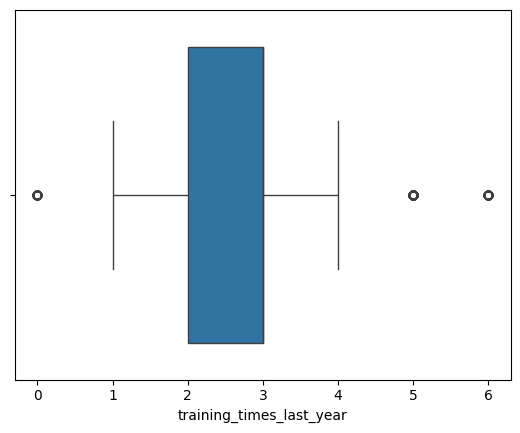

In [129]:
# este grafico nos ayuda a ver si hay valores atipicos/outliers


sns.boxplot(data=df_hr, x="training_times_last_year");

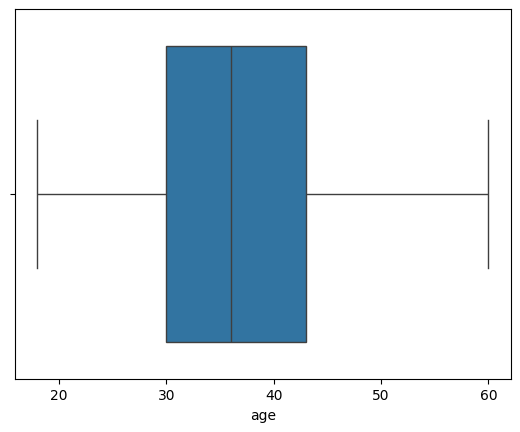

In [130]:
sns.boxplot(data=df_hr, x="age");

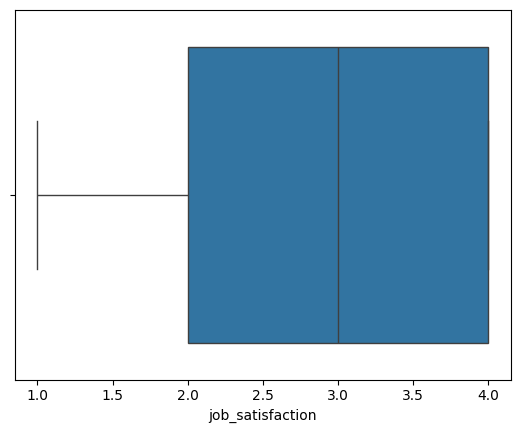

In [131]:
sns.boxplot(data=df_hr, x="job_satisfaction");

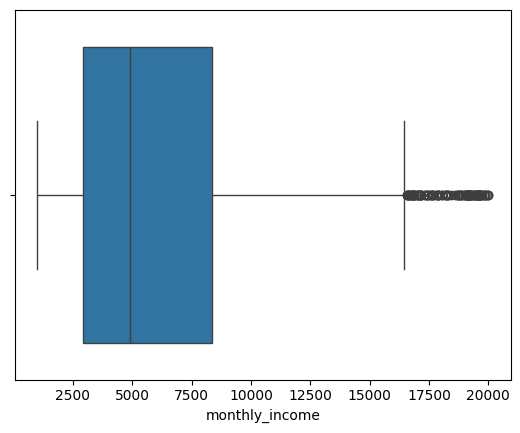

In [132]:
sns.boxplot(data=df_hr, x="monthly_income");

In [133]:

lista_num_media_mediana = ["age", "job_satisfaction", "monthly_income", "training_times_last_year"] 

df_hr[lista_num_media_mediana].agg(["mean", "median"]).T

,mean,median
age,36.942734,36.0
job_satisfaction,2.732130,3.0
monthly_income,6498.683379,4907.0
training_times_last_year,2.798119,3.0


In [134]:
# Imputamos usando la mediana para todas, porque solo en monthly_income encontramos muchos outliers 
# y en las demas no hay mucha diferencia entre media y mediana

mediana_num = df_hr[lista_num_media_mediana].median()

df_hr[lista_num_media_mediana] = df_hr[lista_num_media_mediana].fillna(mediana_num)

df_hr[lista_num_media_mediana].isnull().sum()

age                         0
job_satisfaction            0
monthly_income              0
training_times_last_year    0
dtype: int64

In [135]:
# ahora imputamos usando tecnica avanzada con la columna 'years_with_curr_manager'

iterative_imputer = IterativeImputer(random_state=42, max_iter=20)

iterative_imputado = iterative_imputer.fit_transform(df_hr[["years_with_curr_manager"]])

df_hr[["years_with_curr_manager"]] = iterative_imputado

df_hr.sample(3)


,age,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
1462,39,No,Rarely,Sales,24,1,Marketing,2056,2,Female,60,2,4,Sales Executive,4.0,Married,12031.0,0,No,11,3,1,1,21,2.0,2,20,9,9,6.0
911,25,Yes,Frequently,Sales,24,1,Life Sciences,1273,3,Male,73,1,1,Sales Representative,4.0,Single,1118.0,1,Yes,14,3,4,0,1,4.0,3,1,0,1,0.0
917,34,No,Rarely,Sales,2,3,Marketing,1281,3,Female,86,3,2,Sales Executive,1.0,Single,4538.0,0,Yes,12,3,4,0,4,3.0,3,3,2,0,2.0


In [136]:
print(df_hr.isnull().sum())

age                           0
attrition                     0
business_travel               0
department                    0
distance_from_home            0
education                     0
education_field               0
employee_number               0
environment_satisfaction      0
gender                        0
hourly_rate                   0
job_involvement               0
job_level                     0
job_role                      0
job_satisfaction              0
marital_status                0
monthly_income                0
num_companies_worked          0
over_time                     0
percent_salary_hike           0
performance_rating            0
relationship_satisfaction     0
stock_option_level            0
total_working_years           0
training_times_last_year      0
work_life_balance             0
years_at_company              0
years_in_current_role         0
years_since_last_promotion    0
years_with_curr_manager       0
dtype: int64


In [137]:
# Guardamos el DataFrame limpio en un nuevo archivo CSV
df_hr.to_csv("df_hr_limpio.csv", index=False)

**<u>revision para limpieza</u>**


**<u>hecho:</u>**

- nombre de columnas en minuscula y separado con _ ✔️
- edad cambiar a int ✔️ 
- job role: cambiar a todo en minusculas ✔️ 
- bussines travel lo dejaria solo con rarely o con frequantly. (quitar travel).✔️ 
- departament: poner en minusculas ✔️ 
- marital status hay singled, maried, divorced, escribir homogeneo ✔️
- eliminar columna employee count ✔️
- education_field categorias en minuscula y separado con _ ✔️
- eliminar duplicados ✔️
- ver cuantos nulos tenemos ✔️

- gestion de nulos ✔️



**<u>Eliminamos columnas:</u>**

- 'employee_count', 'over_18', 'standard_hours', 'monthly_rate', 'daily_rate'✔️
- education field La dejamos ✔️
- employee_number - eliminar?